# ACL Tear Detection - Improved Training

Critical fixes for the previous 31% accuracy issue:
1. **MRI-specific normalization** (instead of ImageNet stats)
2. **Per-image normalization** for consistent scaling
3. **Weighted CrossEntropyLoss** for class imbalance
4. **More trainable layers** for medical domain adaptation

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Configuration
DATA_DIR = '/content/drive/MyDrive/dataset/processed_sagittal_resized'

# Training settings
BATCH_SIZE = 32
NUM_EPOCHS = 50
LEARNING_RATE = 1e-4
NUM_CLASSES = 3  # 0: Normal, 1: Partial, 2: Complete
BINARY_MODE = False  # Set True to combine Partial+Complete as "Tear"
CENTER_SLICES = 20  # Use center N slices (ACL region)
RANDOM_SEED = 42

# MRI-specific normalization values (calculated from YOUR dataset)
# This is the KEY FIX - DO NOT use ImageNet values!
MRI_MEAN = 0.132
MRI_STD = 0.190

# Use per-image normalization (recommended for MRI)
USE_PER_IMAGE_NORM = True

In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.transforms as transforms
import torchvision.models as models
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm.notebook import tqdm
import warnings
warnings.filterwarnings('ignore')

# Set seeds for reproducibility
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(RANDOM_SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [ ]:
# Load metadata
data_path = Path(DATA_DIR)
metadata = pd.read_csv(data_path / 'metadata.csv')

print(f"Total patients: {len(metadata)}")
print(f"\nLabel distribution:")
print(metadata['label_name'].value_counts())

# Check class imbalance
class_counts_df = metadata['label'].value_counts().sort_index()
imbalance_ratio = class_counts_df.max() / class_counts_df.min()
print(f"\nClass imbalance ratio: {imbalance_ratio:.1f}x")

# Convert labels for binary mode if needed
if BINARY_MODE:
    metadata['label'] = (metadata['label'] > 0).astype(int)
    NUM_CLASSES = 2
    print(f"\nBinary mode - New distribution:")
    print(metadata['label'].value_counts())

Total patients: 466

Label distribution:
label_name
COMPLETE    295
PARTIAL     142
NORMAL       29
Name: count, dtype: int64

Class imbalance ratio: 10.2x


In [ ]:
# Split data: patient-level split to avoid data leakage
train_df, temp_df = train_test_split(
    metadata, test_size=0.3, stratify=metadata['label'], random_state=RANDOM_SEED
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.5, stratify=temp_df['label'], random_state=RANDOM_SEED
)

print(f"Train: {len(train_df)} patients")
print(f"Val: {len(val_df)} patients")
print(f"Test: {len(test_df)} patients")

print(f"\nTrain label distribution:")
print(train_df['label'].value_counts())

Train: 326 patients
Val: 70 patients
Test: 70 patients

Train label distribution:
label
2    207
1     99
0     20
Name: count, dtype: int64


In [ ]:
class ACLSliceDataset(Dataset):
    """
    Dataset that treats each slice as a separate sample.
    Uses center slices where ACL is typically visible.

    KEY FIX: Uses MRI-specific normalization or per-image normalization
    instead of ImageNet statistics.
    """
    def __init__(self, df, data_dir, transform=None, center_slices=20,
                 use_per_image_norm=True, mri_mean=0.132, mri_std=0.190):
        self.df = df.reset_index(drop=True)
        self.data_dir = Path(data_dir)
        self.transform = transform
        self.center_slices = center_slices
        self.use_per_image_norm = use_per_image_norm
        self.mri_mean = mri_mean
        self.mri_std = mri_std

        # Pre-compute slice indices
        self.samples = []
        for idx, row in self.df.iterrows():
            num_slices = int(row['num_slices'])
            start = max(0, (num_slices - center_slices) // 2)
            end = min(num_slices, start + center_slices)
            for slice_idx in range(start, end):
                self.samples.append((idx, slice_idx, int(row['label'])))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        patient_idx, slice_idx, label = self.samples[idx]
        row = self.df.iloc[patient_idx]

        # Load volume
        file_path = self.data_dir / row['filename']
        volume = np.load(file_path)['data']

        # Get slice and normalize to 0-1
        img = volume[slice_idx].astype(np.float32) / 255.0

        # Apply normalization - THIS IS THE KEY FIX
        if self.use_per_image_norm:
            # Per-image zero-mean normalization (best for MRI)
            img_mean = img.mean()
            img_std = img.std() + 1e-8
            img = (img - img_mean) / img_std
        else:
            # Dataset-level MRI normalization
            img = (img - self.mri_mean) / self.mri_std

        # Convert to 3-channel for pretrained models
        img = np.stack([img, img, img], axis=0)
        img = torch.from_numpy(img)

        if self.transform:
            img = self.transform(img)

        return img, label, patient_idx

    def get_labels(self):
        return [s[2] for s in self.samples]

In [ ]:
# Data augmentation for training
# NOTE: No Normalize transform - normalization is done in Dataset
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.3),
    transforms.RandomRotation(15),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
])

val_transform = None

# Create datasets
train_dataset = ACLSliceDataset(
    train_df, DATA_DIR, train_transform, CENTER_SLICES,
    use_per_image_norm=USE_PER_IMAGE_NORM, mri_mean=MRI_MEAN, mri_std=MRI_STD
)
val_dataset = ACLSliceDataset(
    val_df, DATA_DIR, val_transform, CENTER_SLICES,
    use_per_image_norm=USE_PER_IMAGE_NORM, mri_mean=MRI_MEAN, mri_std=MRI_STD
)
test_dataset = ACLSliceDataset(
    test_df, DATA_DIR, val_transform, CENTER_SLICES,
    use_per_image_norm=USE_PER_IMAGE_NORM, mri_mean=MRI_MEAN, mri_std=MRI_STD
)

print(f"Train samples (slices): {len(train_dataset)}")
print(f"Val samples (slices): {len(val_dataset)}")
print(f"Test samples (slices): {len(test_dataset)}")

Train samples (slices): 6520
Val samples (slices): 1400
Test samples (slices): 1400


In [ ]:
# Verify normalization is working correctly
print("Verifying data normalization...")
sample_img, sample_label, _ = train_dataset[0]
print(f"Sample image shape: {sample_img.shape}")
print(f"Sample image range: {sample_img.min():.3f} to {sample_img.max():.3f}")
print(f"Sample image mean: {sample_img.mean():.3f}")
print(f"Sample image std: {sample_img.std():.3f}")

if abs(sample_img.mean()) < 0.5:
    print("Normalization looks correct!")
else:
    print("WARNING: Mean is not close to 0, check normalization!")

Verifying data normalization...
Sample image shape: torch.Size([3, 224, 224])
Sample image range: -1.162 to 6.210
Sample image mean: 0.017
Sample image std: 0.937
Normalization looks correct!


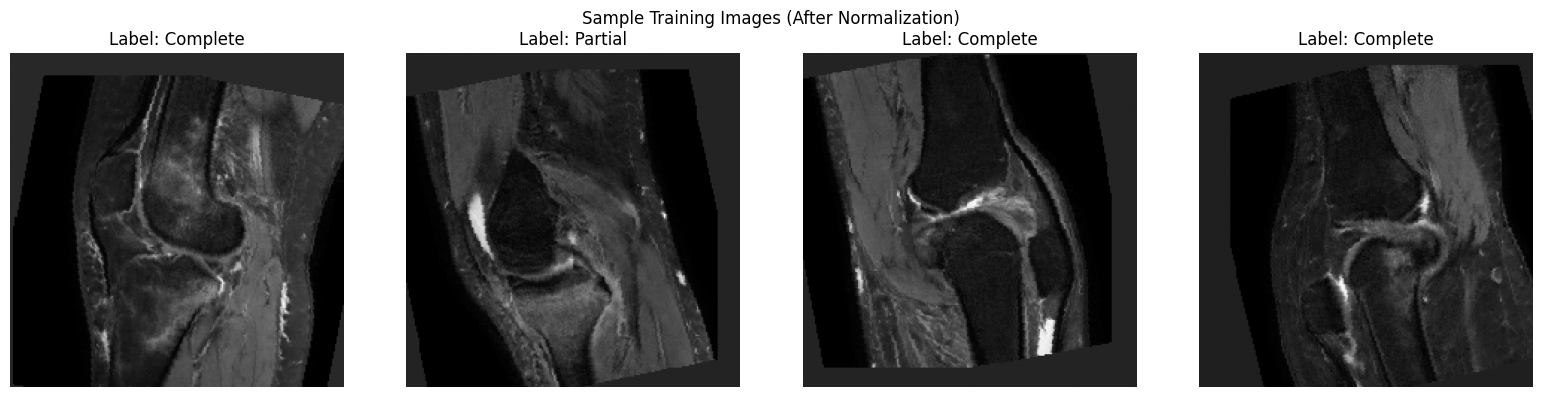

In [ ]:
# Visualize samples
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i in range(4):
    img, label, _ = train_dataset[i * 100]
    img_vis = img[0].numpy()
    axes[i].imshow(img_vis, cmap='gray')
    label_name = ['Normal', 'Partial', 'Complete'][label] if NUM_CLASSES == 3 else ['Normal', 'Tear'][label]
    axes[i].set_title(f'Label: {label_name}')
    axes[i].axis('off')
plt.suptitle('Sample Training Images (After Normalization)')
plt.tight_layout()
plt.show()

In [ ]:
# Weighted sampler for class imbalance
train_labels = train_dataset.get_labels()
class_counts = np.bincount(train_labels)
class_weights = 1.0 / class_counts
sample_weights = [class_weights[label] for label in train_labels]

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

print(f"Class counts: {class_counts}")
print(f"Class weights: {class_weights}")

Class counts: [ 400 1980 4140]
Class weights: [0.0025     0.00050505 0.00024155]


In [ ]:
# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

In [ ]:
class ACLClassifier(nn.Module):
    """
    Transfer learning model using pretrained EfficientNet-B0.
    """
    def __init__(self, num_classes=3, dropout=0.5, freeze_ratio=0.5):
        super(ACLClassifier, self).__init__()

        self.backbone = models.efficientnet_b0(weights='IMAGENET1K_V1')

        # Freeze only early layers for medical domain adaptation
        all_params = list(self.backbone.parameters())
        freeze_count = int(len(all_params) * freeze_ratio)
        for param in all_params[:freeze_count]:
            param.requires_grad = False

        # Replace classifier head
        num_features = self.backbone.classifier[1].in_features
        self.backbone.classifier = nn.Sequential(
            nn.Dropout(p=dropout),
            nn.Linear(num_features, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.Dropout(p=dropout/2),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(p=dropout/3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        return self.backbone(x)

model = ACLClassifier(num_classes=NUM_CLASSES, freeze_ratio=0.5).to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,} ({100*trainable_params/total_params:.1f}%)")

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 135MB/s]


Total parameters: 4,369,279
Trainable parameters: 4,021,739 (92.0%)


In [ ]:
# Loss function - Weighted CrossEntropyLoss (stable, no numerical issues)
class_weights_tensor = torch.FloatTensor(class_weights).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

print(f"Using CrossEntropyLoss with class weights: {class_weights}")

# Optimizer
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=0.01)

# Learning rate scheduler
scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=10, T_mult=2, eta_min=1e-6
)

Using CrossEntropyLoss with class weights: [0.0025     0.00050505 0.00024155]


In [ ]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels, _ in tqdm(loader, desc='Training', leave=False):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    return running_loss / total, 100. * correct / total


def validate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for images, labels, _ in tqdm(loader, desc='Validating', leave=False):
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            probs = torch.softmax(outputs, dim=1)
            _, predicted = outputs.max(1)

            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    return running_loss / total, 100. * correct / total, all_preds, all_labels, all_probs

In [ ]:
# Training loop
history = {
    'train_loss': [], 'train_acc': [],
    'val_loss': [], 'val_acc': []
}

best_val_acc = 0
patience_counter = 0
early_stop_patience = 15

print("Starting training...\n")
print(f"Using {'per-image' if USE_PER_IMAGE_NORM else 'dataset-level MRI'} normalization")
print(f"Loss function: CrossEntropyLoss with class weights")
print()

for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc, _, _, _ = validate(model, val_loader, criterion, device)
    scheduler.step()

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    print(f"Epoch {epoch+1}/{NUM_EPOCHS}")
    print(f"  Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
    print(f"  Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")
    print(f"  LR: {optimizer.param_groups[0]['lr']:.2e}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_acl_model_improved.pth')
        print(f"  New best model saved! (Val Acc: {val_acc:.2f}%)")
        patience_counter = 0
    else:
        patience_counter += 1

    if patience_counter >= early_stop_patience:
        print(f"\nEarly stopping at epoch {epoch+1}")
        break

    print()

Starting training...

Using per-image normalization
Loss function: CrossEntropyLoss with class weights



Training:   0%|          | 0/204 [00:00<?, ?it/s]

Validating:   0%|          | 0/44 [00:00<?, ?it/s]

Epoch 1/50
  Train Loss: 0.8862, Train Acc: 39.36%
  Val Loss: 1.5619, Val Acc: 14.21%
  LR: 9.76e-05
  New best model saved! (Val Acc: 14.21%)



Training:   0%|          | 0/204 [00:00<?, ?it/s]

...

Validating:   0%|          | 0/44 [00:00<?, ?it/s]

Epoch 49/50
  Train Loss: 0.0962, Train Acc: 89.03%
  Val Loss: 1.9197, Val Acc: 53.50%
  LR: 5.44e-05



Training:   0%|          | 0/204 [00:00<?, ?it/s]

Validating:   0%|          | 0/44 [00:00<?, ?it/s]

Epoch 50/50
  Train Loss: 0.1068, Train Acc: 88.62%
  Val Loss: 1.8791, Val Acc: 52.57%
  LR: 5.05e-05



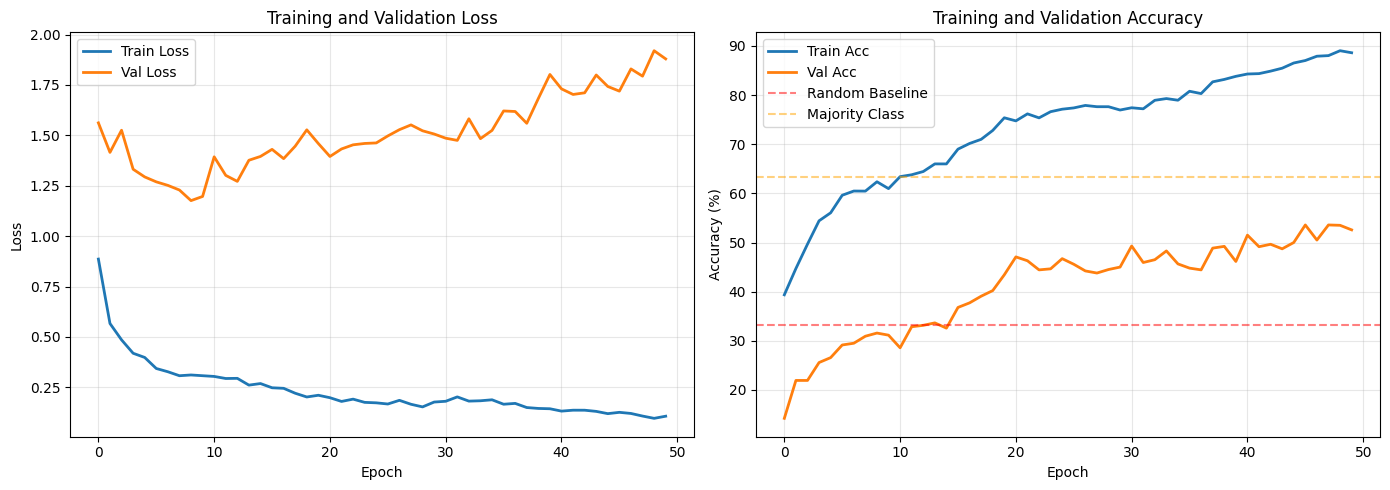


Best validation accuracy: 53.57%


In [ ]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history['train_loss'], label='Train Loss', linewidth=2)
axes[0].plot(history['val_loss'], label='Val Loss', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history['train_acc'], label='Train Acc', linewidth=2)
axes[1].plot(history['val_acc'], label='Val Acc', linewidth=2)
axes[1].axhline(y=33.3, color='r', linestyle='--', label='Random Baseline', alpha=0.5)
axes[1].axhline(y=63.3, color='orange', linestyle='--', label='Majority Class', alpha=0.5)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Training and Validation Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history_improved.png', dpi=150)
plt.show()

print(f"\nBest validation accuracy: {best_val_acc:.2f}%")

In [ ]:
# Load best model and evaluate on test set
model.load_state_dict(torch.load('best_acl_model_improved.pth'))

test_loss, test_acc, test_preds, test_labels, test_probs = validate(
    model, test_loader, criterion, device
)

print(f"Test Accuracy (slice-level): {test_acc:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

Validating:   0%|          | 0/44 [00:00<?, ?it/s]

Test Accuracy (slice-level): 50.29%
Test Loss: 2.1279


In [ ]:
# Classification report
if BINARY_MODE:
    target_names = ['Normal', 'Tear']
else:
    target_names = ['Normal', 'Partial', 'Complete']

print("\nClassification Report (Slice-Level):")
print(classification_report(test_labels, test_preds, target_names=target_names))


Classification Report (Slice-Level):
              precision    recall  f1-score   support

      Normal       0.03      0.01      0.02       100
     Partial       0.33      0.46      0.38       420
    Complete       0.65      0.58      0.61       880

    accuracy                           0.50      1400
   macro avg       0.34      0.35      0.34      1400
weighted avg       0.51      0.50      0.50      1400



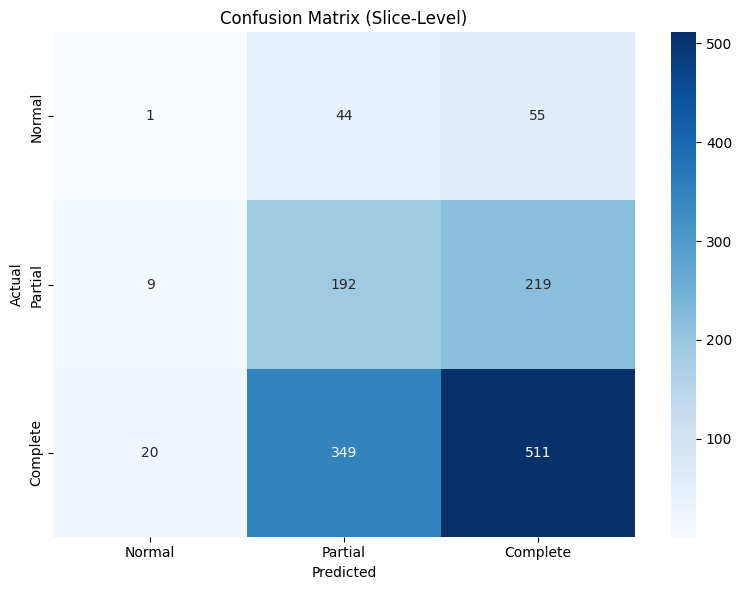

In [19]:
# Confusion matrix
cm = confusion_matrix(test_labels, test_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (Slice-Level)')
plt.tight_layout()
plt.savefig('confusion_matrix_improved.png', dpi=150)
plt.show()

In [20]:
def patient_level_prediction(model, dataset, device):
    model.eval()
    patient_preds = {}
    patient_probs = {}
    patient_labels = {}

    loader = DataLoader(dataset, batch_size=32, shuffle=False)

    with torch.no_grad():
        for images, labels, patient_idxs in tqdm(loader, desc='Patient prediction'):
            images = images.to(device)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            _, preds = outputs.max(1)

            for i, patient_idx in enumerate(patient_idxs.numpy()):
                if patient_idx not in patient_preds:
                    patient_preds[patient_idx] = []
                    patient_probs[patient_idx] = []
                    patient_labels[patient_idx] = labels[i].item()

                patient_preds[patient_idx].append(preds[i].item())
                patient_probs[patient_idx].append(probs[i].cpu().numpy())

    final_preds = []
    final_labels = []
    final_probs = []

    for patient_idx in sorted(patient_preds.keys()):
        preds = patient_preds[patient_idx]
        majority_pred = max(set(preds), key=preds.count)
        avg_prob = np.mean(patient_probs[patient_idx], axis=0)

        final_preds.append(majority_pred)
        final_labels.append(patient_labels[patient_idx])
        final_probs.append(avg_prob)

    return final_preds, final_labels, final_probs

patient_preds, patient_labels_result, patient_probs = patient_level_prediction(
    model, test_dataset, device
)

patient_acc = 100 * np.mean(np.array(patient_preds) == np.array(patient_labels_result))
print(f"\nPatient-Level Accuracy: {patient_acc:.2f}%")

Patient prediction:   0%|          | 0/44 [00:00<?, ?it/s]


Patient-Level Accuracy: 52.86%



Classification Report (Patient-Level):
              precision    recall  f1-score   support

      Normal       0.00      0.00      0.00         5
     Partial       0.33      0.43      0.38        21
    Complete       0.65      0.64      0.64        44

    accuracy                           0.53        70
   macro avg       0.33      0.35      0.34        70
weighted avg       0.51      0.53      0.52        70



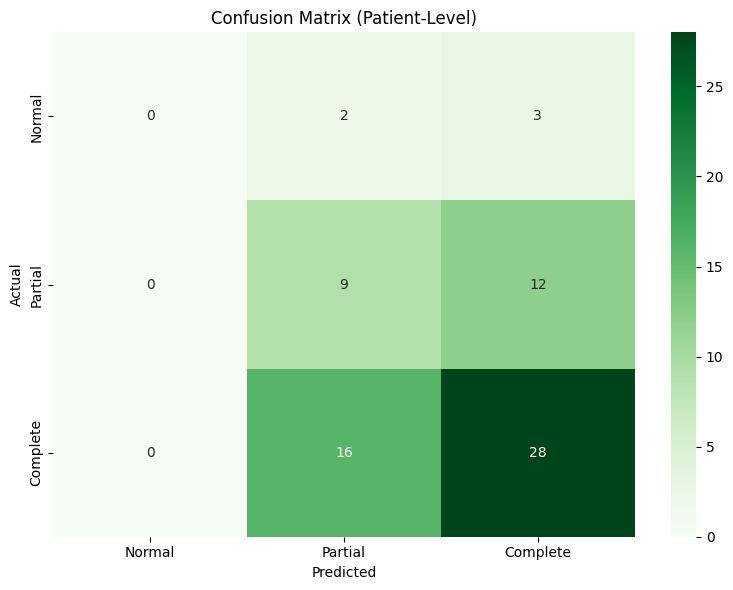

In [21]:
# Patient-level results
print("\nClassification Report (Patient-Level):")
print(classification_report(patient_labels_result, patient_preds, target_names=target_names))

cm_patient = confusion_matrix(patient_labels_result, patient_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_patient, annot=True, fmt='d', cmap='Greens',
            xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (Patient-Level)')
plt.tight_layout()
plt.savefig('confusion_matrix_patient_improved.png', dpi=150)
plt.show()

In [22]:
# Save model to Drive
import shutil

save_path = Path(DATA_DIR).parent / 'acl_model_improved_final.pth'
shutil.copy('best_acl_model_improved.pth', save_path)
print(f"Model saved to: {save_path}")

history_df = pd.DataFrame(history)
history_df.to_csv(Path(DATA_DIR).parent / 'training_history_improved.csv', index=False)
print("Training history saved.")

Model saved to: /content/drive/MyDrive/dataset/acl_model_improved_final.pth
Training history saved.


In [23]:
# Summary
print("="*60)
print("TRAINING SUMMARY")
print("="*60)
print(f"\nKey improvements applied:")
print(f"  - MRI-specific normalization (mean={MRI_MEAN}, std={MRI_STD})")
print(f"  - Per-image normalization: {USE_PER_IMAGE_NORM}")
print(f"  - Weighted CrossEntropyLoss for class imbalance")
print(f"  - 50% of backbone layers trainable")
print(f"  - Cosine annealing LR scheduler")
print(f"  - Gradient clipping for stability")
print(f"\nResults:")
print(f"  Best validation accuracy: {best_val_acc:.2f}%")
print(f"  Test slice-level accuracy: {test_acc:.2f}%")
print(f"  Test patient-level accuracy: {patient_acc:.2f}%")
print(f"\nBaselines:")
print(f"  Random guess: ~33%")
print(f"  Previous model: ~31%")
print(f"  Majority class: ~63%")
print("="*60)

TRAINING SUMMARY

Key improvements applied:
  - MRI-specific normalization (mean=0.132, std=0.19)
  - Per-image normalization: True
  - Weighted CrossEntropyLoss for class imbalance
  - 50% of backbone layers trainable
  - Cosine annealing LR scheduler
  - Gradient clipping for stability

Results:
  Best validation accuracy: 53.57%
  Test slice-level accuracy: 50.29%
  Test patient-level accuracy: 52.86%

Baselines:
  Random guess: ~33%
  Previous model: ~31%
  Majority class: ~63%
